In [ ]:
from torchvision import datasets
data_path = '../data-unversioned/p1ch7/'
cifar10 = datasets.CIFAR10(data_path, train=True, download=True)
cifar10_val = datasets.CIFAR10(data_path, train=False, download=True)

100.0%
c:\Users\zaryab ali\Desktop\pytorch practical\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [2]:
type(cifar10).__mro__


(torchvision.datasets.cifar.CIFAR10,
 torchvision.datasets.vision.VisionDataset,
 torch.utils.data.dataset.Dataset,
 typing.Generic,
 object)

In [4]:
img, label = cifar10[99]
img, label

(<PIL.Image.Image image mode=RGB size=32x32>, 1)

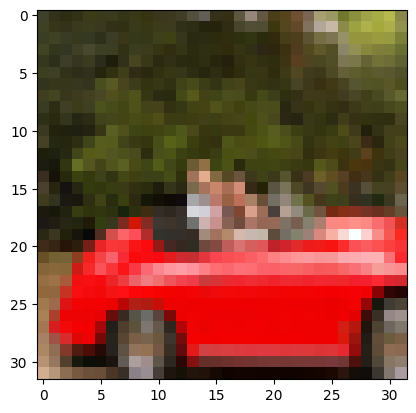

In [6]:
import matplotlib.pyplot as plt
plt.imshow(img)
plt.show()

TRANSFORMING DATA

In [7]:
# trnsforms.totensor is a class/obhect that will take a PIL image or a 
# numpy array and convert it to tensor, as well as normalize it in the way
# images are supposed to be, insteasd of 0-255, it will be 0 to 1
# and it will change 8 bit integer of images to 32 bit integers

from torchvision import transforms

# instanciate
to_tensor = transforms.ToTensor()

img_tensor = to_tensor(img)

img_tensor , img_tensor.shape

(tensor([[[0.2431, 0.1961, 0.1804,  ..., 0.6549, 0.7176, 0.5373],
          [0.2471, 0.2157, 0.2039,  ..., 0.6392, 0.6706, 0.5686],
          [0.2275, 0.2510, 0.2196,  ..., 0.6000, 0.5882, 0.4824],
          ...,
          [0.6745, 0.5608, 0.5098,  ..., 0.3686, 0.5529, 0.5451],
          [0.7176, 0.5882, 0.3137,  ..., 0.3176, 0.5294, 0.5608],
          [0.8196, 0.7137, 0.5451,  ..., 0.2314, 0.5098, 0.6627]],
 
         [[0.2510, 0.1961, 0.1725,  ..., 0.6745, 0.7216, 0.5333],
          [0.2549, 0.2078, 0.1961,  ..., 0.6627, 0.6824, 0.5725],
          [0.2431, 0.2588, 0.2353,  ..., 0.6078, 0.6039, 0.5020],
          ...,
          [0.5294, 0.4314, 0.2196,  ..., 0.2941, 0.4235, 0.4118],
          [0.5725, 0.4627, 0.2510,  ..., 0.2824, 0.4627, 0.4902],
          [0.6824, 0.5922, 0.4275,  ..., 0.2118, 0.4667, 0.6118]],
 
         [[0.1725, 0.1020, 0.0745,  ..., 0.2706, 0.2980, 0.2824],
          [0.1451, 0.1020, 0.1059,  ..., 0.2392, 0.2941, 0.3020],
          [0.1412, 0.1451, 0.1451,  ...,

In [9]:
# instead of loading image as image we can load the entire cifar dataset
# as tensors

data_path = '../data-unversioned/p1ch7/'

tensor_cifar10 = datasets.CIFAR10(data_path, train=True, download=False, 
                transform=transforms.ToTensor())

img_tensor, _ = tensor_cifar10[99]
type(img_tensor), img_tensor.shape, img_tensor.dtype

c:\Users\zaryab ali\Desktop\pytorch practical\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


(torch.Tensor, torch.Size([3, 32, 32]), torch.float32)

NORMALIZE

In [10]:
# aparently there is a way to load the data as normalized tensors
# so we are dong that


# need to learn unsqueeze, stack and view again

import torch
imgs = torch.stack([img_t for img_t, _ in tensor_cifar10], dim=3)

mean = imgs.view(3,-1).mean(dim=1)

std = imgs.view(3,-1).std(dim=1)

mean , std

(tensor([0.4914, 0.4822, 0.4465]), tensor([0.2470, 0.2435, 0.2616]))

c:\Users\zaryab ali\Desktop\pytorch practical\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9806982..2.126078].


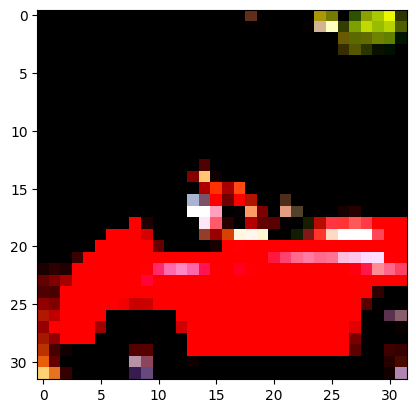

In [11]:
# load as normalizes

transformed_cifar10 = datasets.CIFAR10(
    data_path, train=True, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                            (0.2470, 0.2435, 0.2616))
        ]))


img_t, _ = transformed_cifar10[99]
plt.imshow(img_t.permute(1, 2, 0))
plt.show()

7.2: TELLING BIRDS FROM PLANES

In [ ]:
import torch
import torch.nn as nn
model = nn.Sequential(
    nn.Linear(3072, 512),
    nn.Tanh(),
    nn.Linear(512, 2),
    nn.LogSoftmax(dim=1))
learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.NLLLoss()
n_epochs = 100
for epoch in range(n_epochs):
    for img, label in cifar2:
        out = model(img.view(-1).unsqueeze(0))
        loss = loss_fn(out, torch.tensor([label]))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))